In [ ]:
#Name: Aashish Singh , Section: Q , Roll No.: 20

In [ ]:
"""
Problem Statement: 1
Implement a python program to create a dataset having columns
student_id, student_name, age, height, weight, semester, gender, city and
perform the following:
i. Find the shape of the dataset.
ii. Display the names of the columns.
iii. Compute the no. of null values in each column.
iv. Find unique names.
v. Plot line graph between height and weight, height and age
and weight and age.
vi. Visualize the outliers present in height column using
scatterplot.
vii. Show the outlier in each column using boxplot.
viii. Remove the outlier from the height column using iqr
method.
ix. Remove outlier from weight column using z-score
method.
"""

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = {
    "student_id": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    
    "student_name": ["Aashish Singh", "Aayush Rawat", "Piyush Koli", "Raj Royal","Kartikeya Arya", "Aryan Kumar", "Sneha Rawat", "Rahul",
                     "Kartik Rawat", "Ashmit Sharma"],
    "age": [20, None, 21, 150, 20, 19, None, 22, 23, -5], 
    "height": [170, 158, None, 172, 300, 155, 172, None, 178, 165], 
    "weight": [65, 52, 70, None, 60, 5, None, 54, None, 200], 
    "semester": [3, 2, None, 6, 3, 20, 5, 6, None, 4],  
    "gender": ["Male", "Male", None, "Male", "Male", "Unknown", "Male", None, "Male", "Male"],  
    "city": ["Delhi", None, "Ahmedabad", "Chandigarh", None, "Jaipur", "Mars", "Kochi", None, "Hyderabad"]  
}
df = pd.DataFrame(data)
df.head(10) 

,student_id,student_name,age,height,weight,semester,gender,city
0,101,Aashish Singh,20.0,170.0,65.0,3.0,Male,Delhi
1,102,Aayush Rawat,NaN,158.0,52.0,2.0,Male,NaN
2,103,Piyush Koli,21.0,NaN,70.0,NaN,NaN,Ahmedabad
3,104,Raj Royal,150.0,172.0,NaN,6.0,Male,Chandigarh
4,105,Kartikeya Arya,20.0,300.0,60.0,3.0,Male,NaN
5,106,Aryan Kumar,19.0,155.0,5.0,20.0,Unknown,Jaipur
6,107,Sneha Rawat,NaN,172.0,NaN,5.0,Male,Mars
7,108,Rahul,22.0,NaN,54.0,6.0,NaN,Kochi
8,109,Kartik Rawat,23.0,178.0,NaN,NaN,Male,NaN
9,110,Ashmit Sharma,-5.0,165.0,200.0,4.0,Male,Hyderabad


In [8]:
#i.) Displaying Shape of dataset
df.shape

(10, 8)

In [9]:
#ii.) Displaying Column names
df.columns 

Index(['student_id', 'student_name', 'age', 'height', 'weight', 'semester',
       'gender', 'city'],
      dtype='str')

In [10]:
#iii.) Checking for Null values in each column
df.isnull().sum() 

student_id      0
student_name    0
age             2
height          2
weight          3
semester        2
gender          2
city            3
dtype: int64

In [11]:
#iv.) Check for Unique names 
df["student_name"].unique()

<StringArray>
[ 'Aashish Singh',   'Aayush Rawat',    'Piyush Koli',      'Raj Royal',
 'Kartikeya Arya',    'Aryan Kumar',    'Sneha Rawat',          'Rahul',
   'Kartik Rawat',  'Ashmit Sharma']
Length: 10, dtype: str

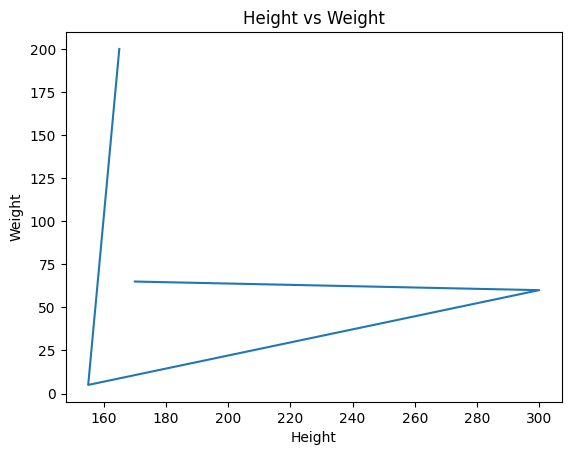

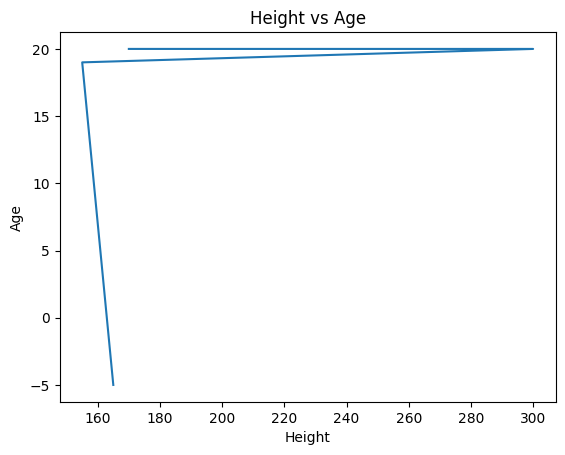

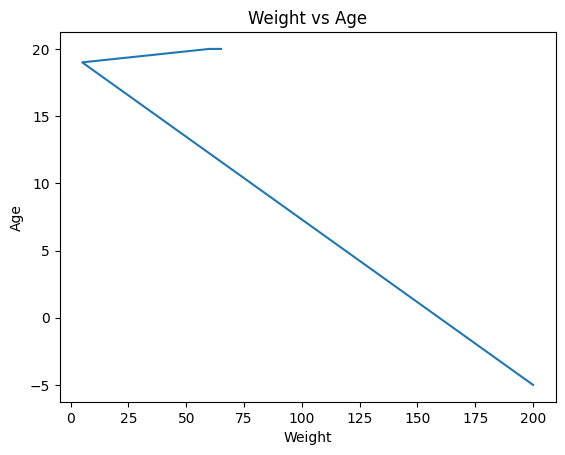

In [12]:
#v.) Plotting line graph between height and weight, height and age and weight and age. 

# Drop rows with nulls for plotting
temp_df = df[["height", "weight", "age"]].dropna()

# Height vs Weight
plt.plot(temp_df["height"], temp_df["weight"])
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height vs Weight")
plt.show()

# Height vs Age
plt.plot(temp_df["height"], temp_df["age"])
plt.xlabel("Height")
plt.ylabel("Age")
plt.title("Height vs Age")
plt.show()

# Weight vs Age
plt.plot(temp_df["weight"], temp_df["age"])
plt.xlabel("Weight")
plt.ylabel("Age")
plt.title("Weight vs Age")
plt.show() 

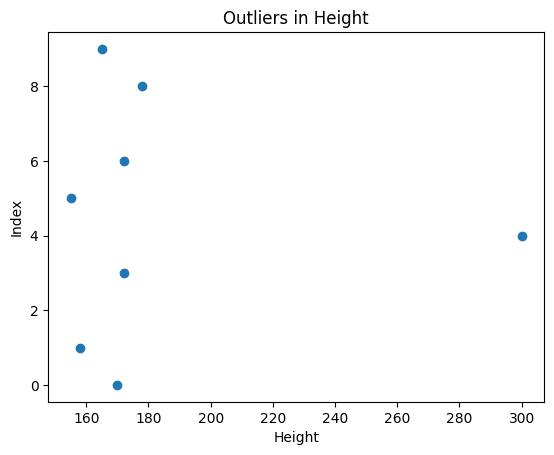

In [13]:
#vi.) Visualizing the outliers present in height column using scatterplot. 
plt.scatter(df["height"], df.index)
plt.xlabel("Height")
plt.ylabel("Index")
plt.title("Outliers in Height")
plt.show() 

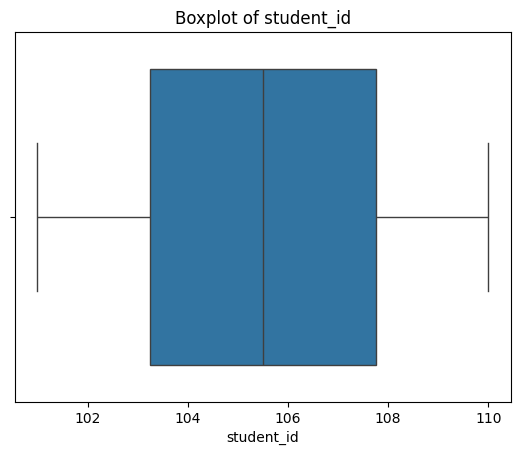

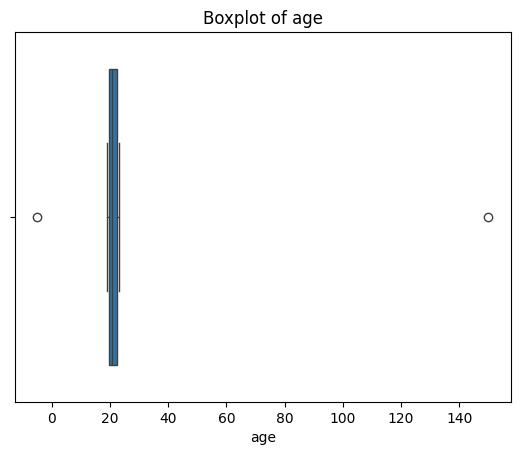

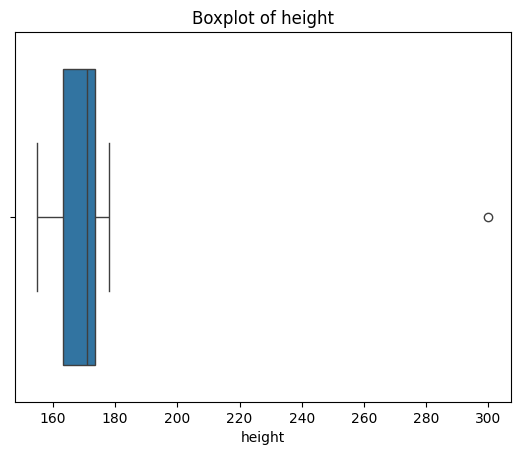

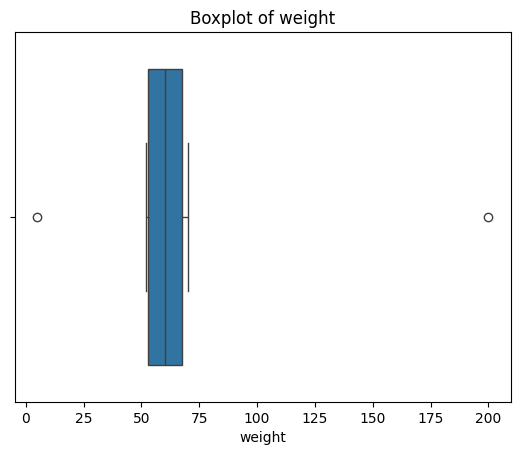

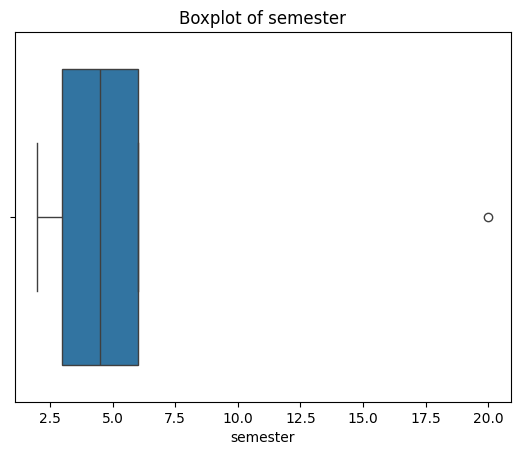

In [14]:
#vii.) Show the outlier in each column using boxplot. 
numeric_df = df.select_dtypes(include=np.number)
for col in numeric_df.columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show() 

In [15]:
#viii. Remove the outlier from the height column using iqr method.
Q1 = df["height"].quantile(0.25)
Q3 = df["height"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_height_outliers = df[(df["height"] >= lower_bound) & (df["height"] <= upper_bound)] 
df_no_height_outliers 

,student_id,student_name,age,height,weight,semester,gender,city
0,101,Aashish Singh,20.0,170.0,65.0,3.0,Male,Delhi
1,102,Aayush Rawat,NaN,158.0,52.0,2.0,Male,NaN
3,104,Raj Royal,150.0,172.0,NaN,6.0,Male,Chandigarh
5,106,Aryan Kumar,19.0,155.0,5.0,20.0,Unknown,Jaipur
6,107,Sneha Rawat,NaN,172.0,NaN,5.0,Male,Mars
8,109,Kartik Rawat,23.0,178.0,NaN,NaN,Male,NaN
9,110,Ashmit Sharma,-5.0,165.0,200.0,4.0,Male,Hyderabad


In [16]:
#ix.) Remove outlier from weight column using z-score method. 
from scipy import stats
z = np.abs(stats.zscore(df["weight"].dropna()))
df_no_weight_outliers = df[df["weight"].notnull()].copy()
df_no_weight_outliers = df_no_weight_outliers[(z < 3)] 
df_no_weight_outliers 

,student_id,student_name,age,height,weight,semester,gender,city
0,101,Aashish Singh,20.0,170.0,65.0,3.0,Male,Delhi
1,102,Aayush Rawat,NaN,158.0,52.0,2.0,Male,NaN
2,103,Piyush Koli,21.0,NaN,70.0,NaN,NaN,Ahmedabad
4,105,Kartikeya Arya,20.0,300.0,60.0,3.0,Male,NaN
5,106,Aryan Kumar,19.0,155.0,5.0,20.0,Unknown,Jaipur
7,108,Rahul,22.0,NaN,54.0,6.0,NaN,Kochi
9,110,Ashmit Sharma,-5.0,165.0,200.0,4.0,Male,Hyderabad
